In [123]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, StackingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
import catboost, lightgbm, xgboost

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform, randint

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

In [111]:
def print_metrics(*metrics, y_true, y_pred):
    metrics_names = {
        r2_score: 'R^2',
        mean_squared_error: 'MSE',
        root_mean_squared_error: 'RMSE',
        mean_absolute_error: 'MAE',
        mean_absolute_percentage_error: 'MAPE' 
    }

    for metric in metrics:
        score = metric(y_true, y_pred)
        if metric == mean_absolute_percentage_error:
            score *= 100 
            print(f"{metrics_names[metric]}: {score} %")
        else:
            print(f"{metrics_names[metric]}: {score}")

# Загрузка и подготовка данных

In [11]:
data = pd.read_csv('/Users/macbook/Desktop/ВУЗ/Машинное обучение и большие данные/lab_1/mumbai_houses.csv')

y = data['price']
X = data.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Решение задачи регрессии

### DecisionTreeRegressor

In [77]:
model = DecisionTreeRegressor()
model.fit(X_train_scaled, y_train)

y_pred_test = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)

In [75]:
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Train
R^2: 0.9998495170580304
MSE: 17118954960.789755
MAE: 95972.54261363637
RMSE: 130839.42433681736
MAPE: 0.6149694275401766

Test
R^2: 0.9987274296374528
MSE: 145041287494.7558
MAE: 250153.58562901744
RMSE: 380842.8645711454
MAPE: 1.4070531422483121



### BaggingRegressor

In [ ]:
algorithms = [DecisionTreeRegressor(), LinearRegression(), Lasso(), Ridge(), ElasticNet()]

In [42]:
for algorithm in algorithms:    
    print(str(algorithm)[:-2])
    bagging_model = BaggingRegressor(estimator=algorithm)
    bagging_model.fit(X_train_scaled, y_train)

    y_pred_test = bagging_model.predict(X_test_scaled)
    y_pred_train = bagging_model.predict(X_train_scaled)
    print('Train')
    print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
    print()
    print('Test')
    print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
    print()
    print('-' * 30)


LinearRegression
Train
R^2: 0.9532127898112908
MSE: 5322517844735.618
MAE: 1485180.2754597566
RMSE: 2307058.26643707
MAPE: 12.273146182548235

Test
R^2: 0.9586067563299108
MSE: 4717797563253.438
MAE: 1422041.1915919117
RMSE: 2172049.162255182
MAPE: 11.216711430900418

------------------------------
Lasso
Train
R^2: 0.9532117406954123
MSE: 5322637192265.8955
MAE: 1488246.2840661544
RMSE: 2307084.1320302766
MAPE: 12.301110337902157

Test
R^2: 0.9585125132602565
MSE: 4728538923073.222
MAE: 1427038.9398970695
RMSE: 2174520.38920614
MAPE: 11.289018149932295

------------------------------
Ridge
Train
R^2: 0.9531965512586358
MSE: 5324365144156.344
MAE: 1486363.6718961196
RMSE: 2307458.589911495
MAPE: 12.30936447812623

Test
R^2: 0.9583656326615386
MSE: 4745279648594.6045
MAE: 1424781.3358061628
RMSE: 2178366.2797139063
MAPE: 11.270318515206968

------------------------------
ElasticNet
Train
R^2: 0.799903019618246
MSE: 22763053075060.496
MAE: 3488136.9006051444
RMSE: 4771064.144932501
MAPE: 

### RandomForestRegressor

In [124]:
bagging_model = RandomForestRegressor()
bagging_model.fit(X_train_scaled, y_train)

y_pred_test = bagging_model.predict(X_test_scaled)
y_pred_train = bagging_model.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()


Train
R^2: 0.9998626913319657
MSE: 15620248202.47934
MAE: 65940.28925619835
RMSE: 124980.99136460447
MAPE: 0.38634859531380367 %

Test
R^2: 0.9990719673892147
MSE: 105772575463.7282
MAE: 166907.62167125804
RMSE: 325226.95992756844
MAPE: 0.9091239570182587 %



### GradientBoostingRegressor

In [45]:
bagging_model = GradientBoostingRegressor()
bagging_model.fit(X_train_scaled, y_train)

y_pred_test = bagging_model.predict(X_test_scaled)
y_pred_train = bagging_model.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()


Train
R^2: 0.9981874925905141
MSE: 206191029381.6205
MAE: 343892.1398779464
RMSE: 454082.62395914306
MAPE: 2.212750207099605

Test
R^2: 0.9975714302434832
MSE: 276796391478.86475
MAE: 389048.5253186229
RMSE: 526114.4281226896
MAPE: 2.343343352197568



### StackingRegressor

In [48]:
bagging_model = StackingRegressor(estimators=[
        ('dt', DecisionTreeRegressor()),
        ('lasso', Lasso()),
        ('ridge', Ridge()),
        ('enet', ElasticNet())
    ], final_estimator=LinearRegression())
bagging_model.fit(X_train_scaled, y_train)

y_pred_test = bagging_model.predict(X_test_scaled)
y_pred_train = bagging_model.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Train
R^2: 0.9995493912992266
MSE: 51261292160.53486
MAE: 149707.98385747147
RMSE: 226409.56729019835
MAPE: 1.3565904252647252

Test
R^2: 0.9963544208897459
MSE: 415505109483.1842
MAE: 372596.9694431486
RMSE: 644596.8581083716
MAPE: 2.3082987740807286



### CatBoostRegressor

In [ ]:
model = catboost.CatBoostRegressor(verbose=200)
model.fit(X_train_scaled, y_train)

y_pred_test = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Learning rate set to 0.05166
0:	learn: 10182621.6393950	total: 1.15ms	remaining: 1.15s
200:	learn: 309806.0238148	total: 179ms	remaining: 710ms
400:	learn: 202040.1331005	total: 349ms	remaining: 522ms
600:	learn: 159908.9695466	total: 520ms	remaining: 345ms
800:	learn: 135914.3051221	total: 691ms	remaining: 172ms
999:	learn: 119851.3702496	total: 863ms	remaining: 0us
Train
R^2: 0.9998737312064027
MSE: 14364350950.709843
MAE: 90746.22253408826
RMSE: 119851.3702496131
MAPE: 0.6060922603565355

Test
R^2: 0.9996999846051771
MSE: 34194273585.206223
MAE: 121340.17729304073
RMSE: 184916.93698849282
MAPE: 0.7530166263262689



### LGBMRegressor

In [70]:
model = lightgbm.LGBMRegressor(verbose=-1)
model.fit(X_train_scaled, y_train)

y_pred_test = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Train
R^2: 0.99954195663856
MSE: 52107059922.86314
MAE: 165828.8017822752
RMSE: 228269.70872821286
MAPE: 1.089215118543623

Test
R^2: 0.9990204192993574
MSE: 111647772262.92392
MAE: 227078.43681736293
RMSE: 334137.35538386594
MAPE: 1.3474440983868226



### XGBRegressor

In [72]:
model = xgboost.XGBRegressor()
model.fit(X_train_scaled, y_train)

y_pred_test = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Train
R^2: 0.9998495170580304
MSE: 17118954960.789755
MAE: 95972.54261363637
RMSE: 130839.42433681736
MAPE: 0.6149694275401766

Test
R^2: 0.9987274296374528
MSE: 145041287494.7558
MAE: 250153.58562901744
RMSE: 380842.8645711454
MAPE: 1.4070531422483121



# Подбор гиперпараметров

### DecisionTreeRegressor

In [108]:
params = {
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(1, 40),
    'max_features': ['sqrt', 'log2', None],
    'max_leaf_nodes': randint(2, 20),
    'min_impurity_decrease': uniform(0.01, 0.1),
    'ccp_alpha': uniform(0.01, 0.05)
}

Лучшие параметры: {'ccp_alpha': 0.04116843612424451, 'max_depth': 18, 'max_features': None, 'max_leaf_nodes': 18, 'min_impurity_decrease': 0.08373056343566426, 'min_samples_leaf': 15, 'min_samples_split': 15}
Лучший score: -8692644692038.791
Train
R^2: 0.9305791458482415
MSE: 7897323510618.082
MAE: 2185643.3929633815
RMSE: 2810217.6980828517
MAPE: 14.452399012802159 %

Test
R^2: 0.9266013671966287
MSE: 8365613812384.1
MAE: 2280633.5546802166
RMSE: 2892337.084847494
MAPE: 14.763374479226258 %



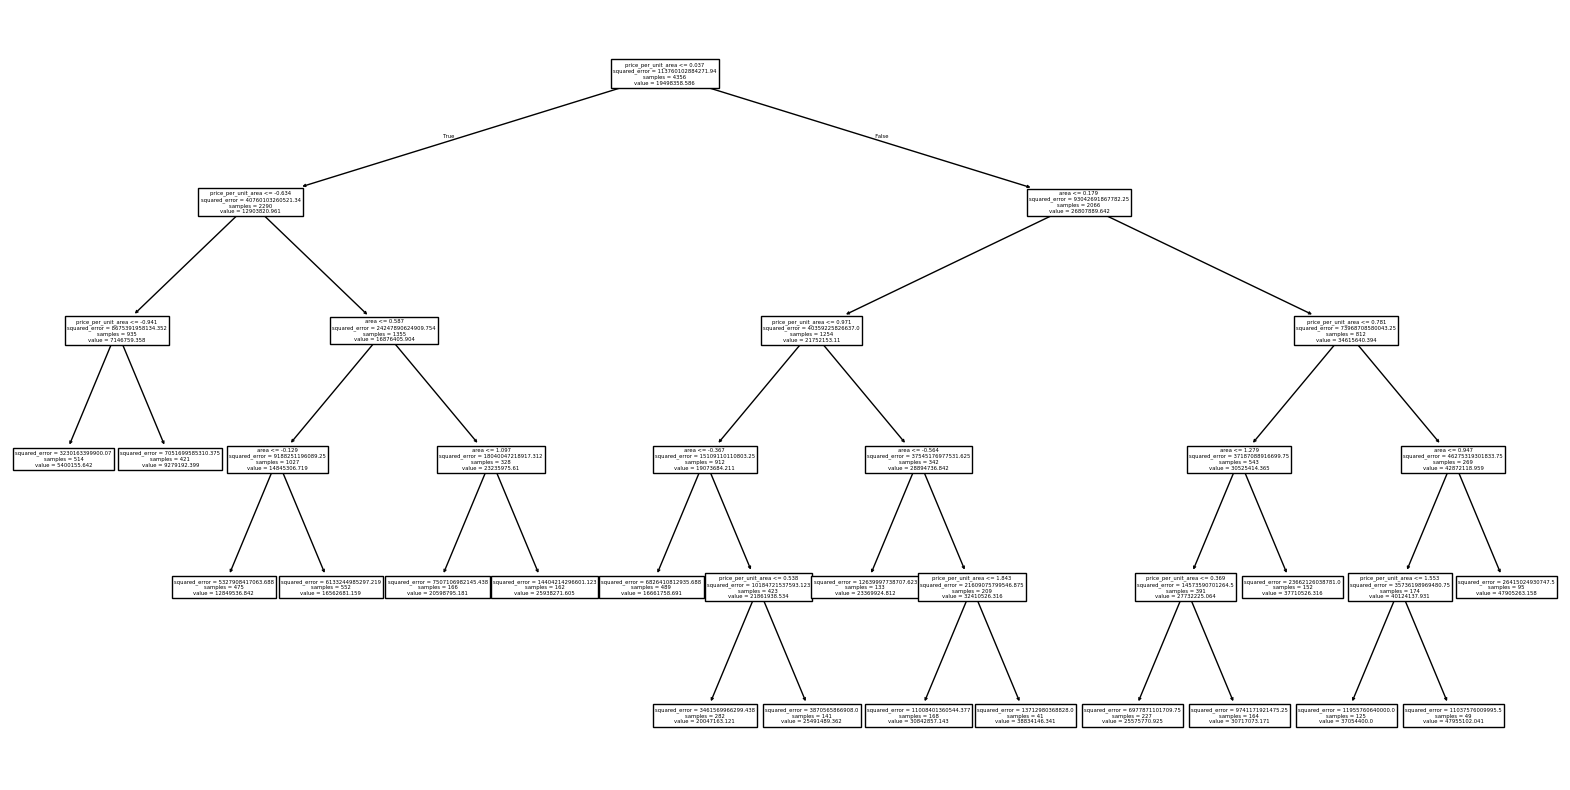

In [122]:
model = DecisionTreeRegressor(criterion='squared_error', splitter='best', random_state=42)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=50, cv=5, scoring='neg_mean_squared_error')
rs.fit(X_train_scaled, y_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = rs.predict(X_test_scaled)
y_pred_train = rs.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

plt.figure(figsize=(20, 10))
plot_tree(rs.best_estimator_, feature_names=X_train.columns)
plt.show()

### BaggingRegressor

In [136]:
params = {
    'n_estimators': randint(2, 100),
    'max_samples': uniform(0.1, 0.9),
    'max_features': uniform(0.1, 0.9),
}

In [133]:
model = BaggingRegressor(estimator=DecisionTreeRegressor(criterion='squared_error', splitter='best', random_state=42), bootstrap=True, bootstrap_features=True)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, cv=2, n_iter=50, scoring='neg_mean_squared_error')
rs.fit(X_train_scaled, y_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = rs.predict(X_test_scaled)
y_pred_train = rs.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Лучшие параметры: {'max_features': 0.9394573480389644, 'max_samples': 0.7191930817445513, 'n_estimators': 82}
Лучший score: -7639549712006.497
Train
R^2: 0.9746762495135046
MSE: 2880832460759.35
MAE: 1217192.94955881
RMSE: 1697301.523230139
MAPE: 8.63137217781679 %

Test
R^2: 0.9186936121139405
MSE: 9266900697684.885
MAE: 2150411.6765421317
RMSE: 3044158.4547596867
MAPE: 14.119659178758216 %



### RandomForestRegressor

In [155]:
params = {
    'n_estimators': randint(2, 100),
    'max_depth': randint(2, 5),
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(10, 40),
    'max_leaf_nodes': randint(2, 20),
}

In [157]:
model = RandomForestRegressor(criterion='squared_error', max_features=1/3, max_samples=1.0, bootstrap=True, random_state=42)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, cv=2, n_iter=50, scoring='neg_mean_squared_error')
rs.fit(X_train_scaled, y_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", -rs.best_score_)

y_pred_test = rs.predict(X_test_scaled)
y_pred_train = rs.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Лучшие параметры: {'max_depth': 4, 'max_leaf_nodes': 18, 'min_samples_leaf': 15, 'min_samples_split': 20, 'n_estimators': 72}
Лучший score: 15197208155464.953
Train
R^2: 0.8755693038219581
MSE: 14155248799175.646
MAE: 2632445.5610988457
RMSE: 3762346.1827928126
MAPE: 19.21694006589878 %

Test
R^2: 0.8671304771785866
MSE: 15143812260609.916
MAE: 2668028.6391125075
RMSE: 3891505.1407662197
MAPE: 18.450504202144337 %



### GradientBoostingRegressor

In [162]:
params = {
    'learning_rate': uniform(0.1, 0.5),
    'n_estimators': randint(2, 100),
    'max_depth': randint(1, 3),
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(10, 40),
    'max_leaf_nodes': randint(2, 20),
    'ccp_alpha': uniform(0.0, 0.3)
}

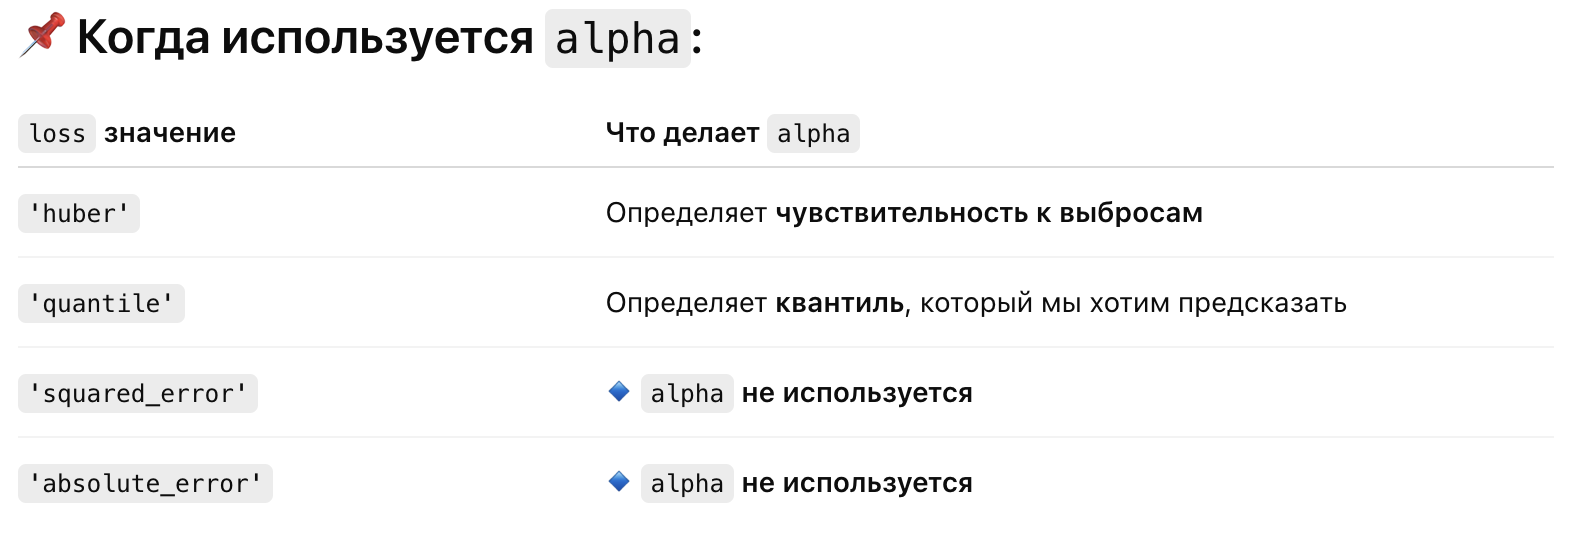

In [164]:
model = GradientBoostingRegressor(loss='squared_error', subsample=1.0, criterion='friedman_mse', random_state=42, max_features=1/3)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, cv=3, n_iter=50, scoring='neg_mean_squared_error')
rs.fit(X_train_scaled, y_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", -rs.best_score_)

y_pred_test = rs.predict(X_test_scaled)
y_pred_train = rs.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Лучшие параметры: {'ccp_alpha': 0.042161188493274944, 'learning_rate': 0.46462679651667393, 'max_depth': 2, 'max_leaf_nodes': 8, 'min_samples_leaf': 26, 'min_samples_split': 9, 'n_estimators': 92}
Лучший score: 1982675554239.082
Train
R^2: 0.985955790388963
MSE: 1597670730279.8518
MAE: 944876.2709170241
RMSE: 1263990.0040268719
MAPE: 6.340945808831555 %

Test
R^2: 0.9826257111884124
MSE: 1980235665314.627
MAE: 1028121.1184500072
RMSE: 1407208.4654785967
MAPE: 6.5269724928583965 %

